导入numpy包

In [23]:
import numpy as np

定义z方向自旋劈裂矢量
$$\left|0\right>=\left[\begin{matrix}1\\0\end{matrix}\right],\left|1\right>=\left[\begin{matrix}0\\1\end{matrix}\right]$$

In [24]:
zero_qubit = np.matrix('1; 0')
one_qubit = np.matrix('0; 1')
print(zero_qubit)

[[1]
 [0]]


编写混合态构造函数

In [25]:
def zero_to_one_qubit(precentage_zero : float, precentage_one: float):
    if not precentage_zero + precentage_one == 100:
        raise Exception('the sum of the square of precentages must be equal to 100 and both precentage must be positive.')
    return np.sqrt(precentage_zero/100.)*zero_qubit + np.sqrt(precentage_one/100.)*one_qubit

In [26]:
qb_50_50 = zero_to_one_qubit(50, 50)
qb_50_50

matrix([[0.70710678],
        [0.70710678]])

$$\left|\psi_1\right>=\frac{1}{\sqrt{2}}\left[\begin{matrix}1\\0\end{matrix}\right]+\frac{1}{\sqrt{2}}\left[\begin{matrix}0\\1\end{matrix}\right]$$

In [27]:
qb_10_90 = zero_to_one_qubit(10, 90)
qb_10_90

matrix([[0.31622777],
        [0.9486833 ]])

$$\left|\psi_1\right>=\sqrt{10\%}\left[\begin{matrix}1\\0\end{matrix}\right]+{\sqrt{90\%}}\left[\begin{matrix}0\\1\end{matrix}\right]$$

定义x,y方向自旋劈裂矢量

$$\left|+\right>=\frac{1}{\sqrt2}\left[\begin{matrix}1\\1\end{matrix}\right],\left|-\right>=\frac{1}{\sqrt2}\left[\begin{matrix}1\\-1\end{matrix}\right]$$
$$\left|\circlearrowright\right>=\frac{1}{\sqrt2}\left[\begin{matrix}1\\i\end{matrix}\right],\left|\circlearrowleft\right>=\frac{1}{\sqrt2}\left[\begin{matrix}1\\-i\end{matrix}\right]$$

In [28]:
# 正负基态 x轴
plus_qubit = 1 / np.sqrt(2) * np.matrix('1; 1')
minus_qubit = 1 / np.sqrt(2) * np.matrix('1; -1')
 
# 顺逆基态 y轴
clockwise_qubit = 1/np.sqrt(2) * np.matrix([[1], [1j]])
counterclockwise_qubit = 1/np.sqrt(2) * np.matrix([[1], [-1j]])
print(plus_qubit)
print(clockwise_qubit)

[[0.70710678]
 [0.70710678]]
[[0.70710678+0.j        ]
 [0.        +0.70710678j]]


转换到Bloch球面坐标
![](05_1.jpg)

In [29]:
def get_bloch_coordinates(qubit):
    def get_x_bloch(qubit):
        qubit_x_basis = 1./np.sqrt(2) * np.matrix('1 1; 1 -1') * qubit
        prob_zero_qubit = (qubit_x_basis.item(0) * qubit_x_basis.item(0).conjugate()).real
        prob_one_qubit = (qubit_x_basis.item(1) * qubit_x_basis.item(1).conjugate()).real
        return prob_zero_qubit - prob_one_qubit
    def get_y_bloch(qubit):
        qubit_y_basis = 1./np.sqrt(2) * np.matrix('1 1; 1 -1') * np.matrix([[1,0], [0, -1j]]) * qubit
        prob_zero_qubit = (qubit_y_basis.item(0) * qubit_y_basis.item(0).conjugate()).real
        prob_one_qubit = (qubit_y_basis.item(1) * qubit_y_basis.item(1).conjugate()).real
        return prob_zero_qubit - prob_one_qubit
    def get_z_bloch(qubit):
        qubit_z_basis = qubit
        prob_zero_qubit = (qubit_z_basis.item(0) * qubit_z_basis.item(0).conjugate()).real
        prob_one_qubit = (qubit_z_basis.item(1) * qubit_z_basis.item(1).conjugate()).real
        return prob_zero_qubit - prob_one_qubit
    return (get_x_bloch(qubit), get_y_bloch(qubit), get_z_bloch(qubit))
get_bloch_coordinates(qb_10_90)

(0.5999999999999998, 0.0, -0.7999999999999999)

导入绘图库matplotlib.pyplot

In [30]:
import matplotlib.pyplot as plt

编写Bloch球面绘制函数

<Axes3D: >

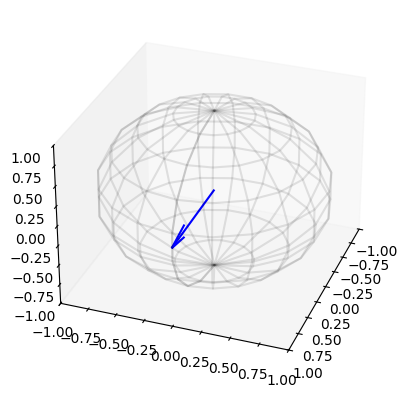

In [31]:
def plot_bloch(qubit, color='b'):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # 绘制球体
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = np.cos(u)*np.sin(v)
    y = np.sin(u)*np.sin(v)
    z = np.cos(v)
    ax.plot_wireframe(x, y, z, color="k", alpha=.1)
    ax.grid(0)
 
    coordinates = get_bloch_coordinates(qubit)
    ax.quiver([0],[0],[0],[coordinates[0]], [coordinates[1]], [coordinates[2]],length=1,color=color,arrow_length_ratio=0.3)
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    ax.view_init(azim=20)
    return ax
plot_bloch(qb_50_50)

<Axes3D: >

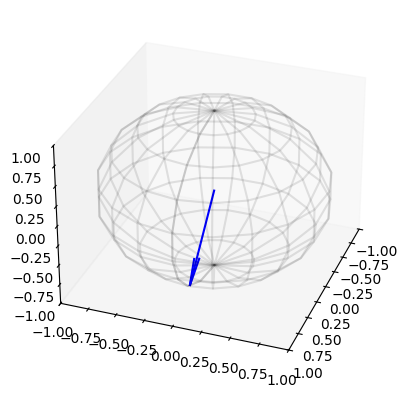

In [32]:
plot_bloch(qb_10_90)

<Axes3D: >

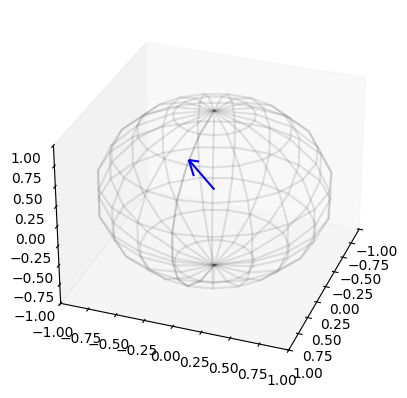

In [33]:
plot_bloch(zero_to_one_qubit(90, 10))